# 🚗 KSI Toronto — Step 3: Model Building and Evaluation

## Objective

The purpose of this notebook is to build, train, and evaluate multiple machine learning classification models to predict whether a collision is fatal or non-fatal.

In this step, we will:
- load the prepared training and testing datasets from Step 2
- train multiple supervised classification models
- evaluate model performance using appropriate metrics
- compare the models
- select the best-performing model
- save the final model for prediction and deployment

In [2]:
# ============================================================
# Step 3 — Model Building and Evaluation
# ============================================================

import pickle
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import matplotlib.pyplot as plt

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 3.1 Load Prepared Training and Testing Data

In this section, we load the processed datasets created in Step 2.  
These files are already cleaned, encoded, scaled, and prepared for machine learning.

In [3]:
# ============================================================
# 3.1 — Load Prepared Training and Testing Data
# ============================================================

MODELS_PATH = r'C:\Users\HP\Desktop\Artificial Intelligence - Software Engineering Technology (Fast-Track)\26W --Supervised Learning (SEC. 402)\COMP247_KSI_Project\models\\'

X_train = pickle.load(open(MODELS_PATH + 'X_train.pkl', 'rb'))
X_test  = pickle.load(open(MODELS_PATH + 'X_test.pkl', 'rb'))
y_train = pickle.load(open(MODELS_PATH + 'y_train.pkl', 'rb'))
y_test  = pickle.load(open(MODELS_PATH + 'y_test.pkl', 'rb'))

print("✅ Prepared datasets loaded successfully")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

✅ Prepared datasets loaded successfully
X_train shape: (26028, 34)
X_test shape : (3788, 34)
y_train shape: (26028,)
y_test shape : (3788,)


## 3.2 Define Machine Learning Models

In this section, we define several supervised classification models.  
The goal is to compare different algorithms and identify which model performs best for predicting fatal collision outcomes.

In [4]:
# ============================================================
# 3.2 — Define Machine Learning Models
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

print("✅ Machine learning models defined successfully")
print(f"Total models: {len(models)}")

for model_name in models.keys():
    print(f"• {model_name}")

✅ Machine learning models defined successfully
Total models: 5
• Logistic Regression
• Decision Tree
• Random Forest
• SVM
• Neural Network


## 3.3 Train and Evaluate Models

In this section, each model is trained using the balanced training dataset created with SMOTE.  
Then, the models are evaluated on the test set using accuracy, precision, recall, F1-score, and ROC-AUC.

In [5]:
# ============================================================
# 3.3 — Train and Evaluate Models
# ============================================================

results = []

for model_name, model in models.items():
    print("=" * 60)
    print(f"Training model: {model_name}")
    print("=" * 60)
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Predicted probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print()

results_df = pd.DataFrame(results)
print("✅ All models trained and evaluated successfully")
results_df

Training model: Logistic Regression
Accuracy : 0.6233
Precision: 0.2061
Recall   : 0.5861
F1-Score : 0.3049
ROC-AUC  : 0.6509

Training model: Decision Tree
Accuracy : 0.8904
Precision: 0.6049
Recall   : 0.6423
F1-Score : 0.6231
ROC-AUC  : 0.7866

Training model: Random Forest
Accuracy : 0.9314
Precision: 0.9790
Recall   : 0.5243
F1-Score : 0.6829
ROC-AUC  : 0.9339

Training model: SVM
Accuracy : 0.8699
Precision: 0.5375
Recall   : 0.5506
F1-Score : 0.5439
ROC-AUC  : 0.8375

Training model: Neural Network
Accuracy : 0.8976
Precision: 0.6209
Recall   : 0.7022
F1-Score : 0.6591
ROC-AUC  : 0.8906

✅ All models trained and evaluated successfully


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.623284,0.206057,0.586142,0.304920,0.650855
1,Decision Tree,0.890444,0.604938,0.642322,0.623070,0.786632
2,Random Forest,0.931362,0.979021,0.524345,0.682927,0.933908
3,SVM,0.869852,0.537477,0.550562,0.543941,0.837456
4,Neural Network,0.897571,0.620861,0.702247,0.659051,0.890646


## 3.4 Model Comparison

The models are compared using multiple evaluation metrics.  
Because the dataset is imbalanced, F1-score, Recall, and ROC-AUC are more important than accuracy alone.

In [6]:
# ============================================================
# 3.4 — Model Comparison
# ============================================================

results_df_sorted = results_df.sort_values(by="F1-Score", ascending=False)

print("✅ Models ranked by F1-Score")
results_df_sorted

✅ Models ranked by F1-Score


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.931362,0.979021,0.524345,0.682927,0.933908
4,Neural Network,0.897571,0.620861,0.702247,0.659051,0.890646
1,Decision Tree,0.890444,0.604938,0.642322,0.623070,0.786632
3,SVM,0.869852,0.537477,0.550562,0.543941,0.837456
0,Logistic Regression,0.623284,0.206057,0.586142,0.304920,0.650855


## 3.5 Best Model Selection

Based on the comparison results, Random Forest is selected as the best overall model.

Random Forest achieved the strongest overall performance, with the highest Accuracy, Precision, F1-Score, and ROC-AUC among the tested models. Although the Neural Network achieved higher Recall, Random Forest provides a better balance between detecting fatal collisions and avoiding false fatal predictions.

For this reason, Random Forest is selected as the final model for prediction.

In [7]:
# ============================================================
# 3.5 — Best Model Selection
# ============================================================

best_model_name = "Random Forest"
best_model = models[best_model_name]

print("✅ Best model selected")
print(f"Best Model: {best_model_name}")

best_model_results = results_df[results_df["Model"] == best_model_name]
best_model_results

✅ Best model selected
Best Model: Random Forest


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.931362,0.979021,0.524345,0.682927,0.933908


## 3.6 Confusion Matrix for Best Model

The confusion matrix helps us understand how many fatal and non-fatal collisions were correctly or incorrectly predicted by the best model.

✅ Confusion Matrix for Random Forest
[[3248    6]
 [ 254  280]]


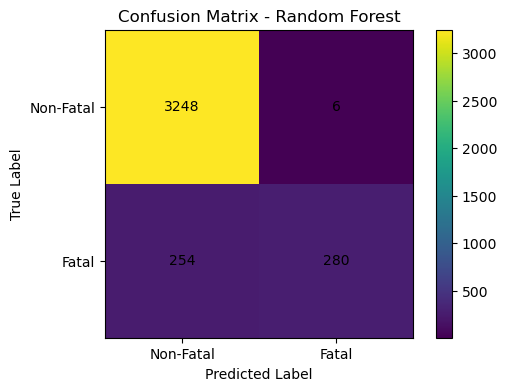

In [8]:
# ============================================================
# 3.6 — Confusion Matrix for Best Model
# ============================================================

# Predict using the best model
y_pred_best = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

print("✅ Confusion Matrix for Random Forest")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Non-Fatal", "Fatal"])
plt.yticks([0, 1], ["Non-Fatal", "Fatal"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 3.7 Classification Report for Best Model

The classification report provides detailed precision, recall, and F1-score values for each class.  
This is especially useful because the dataset is imbalanced and fatal collisions are less frequent than non-fatal collisions.

In [9]:
# ============================================================
# 3.7 — Classification Report for Best Model
# ============================================================

print("✅ Classification Report - Random Forest")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["Non-Fatal", "Fatal"]
))

✅ Classification Report - Random Forest
              precision    recall  f1-score   support

   Non-Fatal       0.93      1.00      0.96      3254
       Fatal       0.98      0.52      0.68       534

    accuracy                           0.93      3788
   macro avg       0.95      0.76      0.82      3788
weighted avg       0.93      0.93      0.92      3788



## 3.8 Save Final Model

The selected Random Forest model is saved so it can be reused later for prediction and possible deployment.

In [10]:
# ============================================================
# 3.8 — Save Final Model
# ============================================================

FINAL_MODEL_PATH = MODELS_PATH + "best_random_forest_model.pkl"

with open(FINAL_MODEL_PATH, "wb") as file:
    pickle.dump(best_model, file)

print("✅ Final Random Forest model saved successfully")
print(f"Model saved at: {FINAL_MODEL_PATH}")

✅ Final Random Forest model saved successfully
Model saved at: C:\Users\HP\Desktop\Artificial Intelligence - Software Engineering Technology (Fast-Track)\26W --Supervised Learning (SEC. 402)\COMP247_KSI_Project\models\\best_random_forest_model.pkl


## 3.9 Step 3 Summary

In this step, five machine learning models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- Neural Network

Based on the comparison results, Random Forest was selected as the best overall model. It achieved the strongest balance across Accuracy, Precision, F1-Score, and ROC-AUC.

The final Random Forest model was saved for future prediction and possible deployment.

### Next Step

The next step is to build a prediction workflow where the saved model can be loaded and used to predict whether a new collision case is fatal or non-fatal.